# 청킹 전략별 답변 품질 비교 실험
- 5주차에서는 chunk_size 300자와 overlap 50자로 고정해서 실습했다. 
- 이번에는 동일한 문서와 동일한 질문을 두고 청킹 파라미터만 바꿔서 답변 품질이 어떻게 변하는지 비교한다.

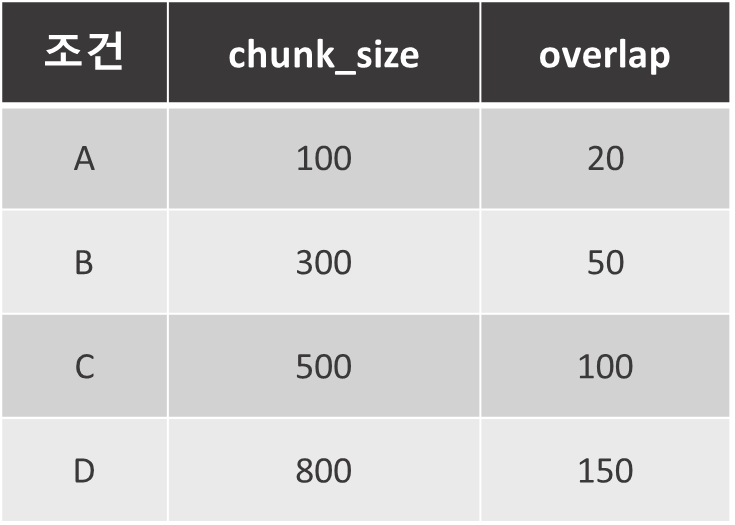

In [1]:
# 5주차 - parsing.ipynb에서 함수 가져오기 
import fitz

def load_pdf(path: str) -> str:
    doc = fitz.open(path)
    return "\n\n".join(page.get_text() for page in doc)

def chunk_text_fixed_overlap(text: str, chunk_size: int = 300, overlap: int = 50):
    """고정 길이로 자르되, 인접 청크가 overlap만큼 겹치도록 한다."""
    assert 0 <= overlap < chunk_size, "overlap은 chunk_size보다 작아야 한다"

    chunks = []
    step = chunk_size - overlap  
    for start in range(0, len(text), step):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        if end == len(text): 
            break
    return chunks


# 파라미터별 답변 품질 비교

동일한 문서(`part3.pdf`)와 동일한 질문에 대해 `chunk_size`와 `overlap`만 바꿔가며 RAG 답변이 어떻게 달라지는지 비교한다.

In [2]:
from dotenv import load_dotenv
import os
import chromadb
import google.generativeai as genai

load_dotenv()
genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

def run_rag(chunk_size: int, overlap: int, query: str) -> tuple[int, str]:
    # 1. 청킹
    text = load_pdf("part3.pdf")
    chunks = chunk_text_fixed_overlap(text, chunk_size=chunk_size, overlap=overlap)

    # 2. 설정별로 분리된 컬렉션에 저장
    client = chromadb.PersistentClient(path="./db")
    col = client.get_or_create_collection(name=f"cmp_{chunk_size}_{overlap}")
    col.upsert(
        ids=[f"c{i}" for i in range(len(chunks))],
        documents=chunks,
        metadatas=[{"source": "part3.pdf"}] * len(chunks)
    )

    # 3. 검색 + 답변 생성
    results = col.query(query_texts=[query], n_results=3)
    context = "\n\n".join(results["documents"][0])
    prompt = f"""다음 문서를 참고해 답하라.
검색 결과에 없는 내용은 모른다고 답하라.

[문서]
{context}

[질문] {query}
"""
    model = genai.GenerativeModel("gemini-2.5-flash")
    return len(chunks), model.generate_content(prompt).text.strip()

d:\GitHub\1_lecture-materials\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\esdl\AppData\Local\Temp\ipykernel_24188\1899930143.py:4: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [3]:

# 비교할 파라미터 조합
configs = [
    (100,   0),   # 오버랩 없음, 작은 청크
    (100,  20),   # 오버랩 20%, 작은 청크
    (300,   0),   # 오버랩 없음, 중간 청크
    (300,  50),   # 오버랩 17%, 중간 청크
    (500,  50),   # 오버랩 10%, 큰 청크
    (500, 100),   # 오버랩 20%, 큰 청크
]
query = "청킹에서 오버랩이 필요한 이유는 무엇인가요?"

for chunk_size, overlap in configs:
    n_chunks, answer = run_rag(chunk_size, overlap, query)
    print(f"\n{'='*60}")
    print(f"chunk_size={chunk_size:4d}, overlap={overlap:3d}  →  총 {n_chunks}개 청크")
    print(f"{'='*60}")
    print(answer)


chunk_size= 100, overlap=  0  →  총 27개 청크
제공된 문서에 따르면, '오버랩은 왜 필요한가?'라는 질문 다음에 "고정 길이 청킹은 의미 단위를 무시하고 글자 수만 보고 자르기 때문에, 청크 경계가 문장 한가운데 떨어지는 일이 흔하다. 오버랩은 인접"이라는 내용이 나옵니다.

하지만 이 문장에서 오버랩이 필요한 구체적인 이유에 대한 설명은 불완전하게 끝나있어, 문서만으로는 오버랩이 필요한 명확한 이유를 알 수 없습니다.

chunk_size= 100, overlap= 20  →  총 34개 청크
문서에 따르면, "오버랩은 인접"에서 설명이 끊겨 있어 오버랩이 필요한 정확한 이유를 알 수 없습니다.


ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 56.4684967s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 5
}
, retry_delay {
  seconds: 56
}
]

# ChromaDB where 필터 사용법

`query()`에 `where` 인자를 넘기면 메타데이터 조건에 맞는 청크만 임베딩 유사도 검색의 후보가 된다.

지원 연산자: `$eq` · `$ne` · `$gt` · `$gte` · `$lt` · `$lte` · `$in` · `$nin` — 비교와 집합 연산자가 모두 제공된다.

In [4]:
import fitz
import chromadb
import re

# 페이지 번호를 메타데이터에 포함해 저장
# doc = fitz.open("part3.pdf")
client = chromadb.PersistentClient(path="./db")
col = client.get_or_create_collection(name="where_demo")
pdf_files = ["part3.pdf", "part4.pdf"]

for fname in pdf_files:
    doc = fitz.open(fname)
    for i, page in enumerate(doc):
        text = page.get_text().strip()
        if text:
            col.upsert(
                ids=[f"{fname}_page_{i+1}"],   # 파일별로 id 분리 (충돌 방지)
                documents=[text],
                metadatas=[{
                    "source": fname,           # 파일명을 그대로 저장
                    "page": i + 1,
                    "category": "manual",
                    "lang": "ko",
                    "year": 2025,
                    "n_tokens": len(text) // 4,
                }]
            )

print(f"저장 완료: {col.count()}개 페이지")

# 두 PDF 모두 관련 있는 질문 → 필터 유무에 따라 결과가 달라지는 것을 확인
question = "검색 정확도를 높이려면 어떤 점을 고려해야 하나요?"

# 세 가지 검색 방식을 같은 질문으로 비교
filters = {
    "필터 없음":      None,
    "source 필터":    {"source": "part4.pdf"},
    "page 범위 필터": {"page": {"$gte": 2}},
}

for label, where in filters.items():
    results = col.query(query_texts=[question], n_results=3, where=where)
    print(f"\n[{label}]")
    for doc_text, meta in zip(results["documents"][0], results["metadatas"][0]):
        print(f"  page={meta['page']} | {doc_text[:60]}...")


d:\GitHub\1_lecture-materials\.venv311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\esdl\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5030.66it/s]


저장 완료: 32개 페이지

[필터 없음]
  page=1 | % 수준에서 시작해 데이터에 맞게 조정
한다.
청킹이 왜 중요한가?
RAG의 검색 정확도는 청크 크기에 크게...
  page=1 | Part 4.  
메타데이터 필터링 — 검색 범위를 좁혀 정확도 높이기
메타데이터는 청크 본문이 아닌 부가 ...
  page=1 | Part 4.  
메타데이터 필터링 — 검색 범위를 좁혀 정확도 높이기
메타데이터는 청크 본문이 아닌 부가 ...

[source 필터]
  page=1 | Part 4.  
메타데이터 필터링 — 검색 범위를 좁혀 정확도 높이기
메타데이터는 청크 본문이 아닌 부가 ...
  page=1 | Part 4.  
메타데이터 필터링 — 검색 범위를 좁혀 정확도 높이기
메타데이터는 청크 본문이 아닌 부가 ...
  page=3 |  돌아온다.
3. where={"source": "part3.pdf"} 를 추가하면 해당 문서의 청크만 결과...

[page 범위 필터]
  page=2 | 경험적으로 한국어 문서는 200500자, 오버랩 1020% 정도가 출발점으로 무난하다.
"정확한 검색은 좋은...
  page=2 | 경험적으로 한국어 문서는 200500자, 오버랩 1020% 정도가 출발점으로 무난하다.
"정확한 검색은 좋은...
  page=3 |  돌아온다.
3. where={"source": "part3.pdf"} 를 추가하면 해당 문서의 청크만 결과...


# K 값을 바꿔 가며 답변 비교

In [5]:
import fitz
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

# ── 다국어 임베딩 모델 지정 ───────────────────────────────
embedding_fn = SentenceTransformerEmbeddingFunction(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

# ── 5주차에서 만든 청킹 함수 ──────────────────────────────
def chunk_text_fixed_overlap(text, chunk_size=300, overlap=50):
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

# ── ChromaDB 초기화 ──────────────────────────────────────
client = chromadb.PersistentClient(path="./db")
try:
    client.delete_collection("where_demo")
except:
    pass

# 컬렉션 생성 시 embedding_function 지정
col = client.get_or_create_collection(
    name="where_demo",
    embedding_function=embedding_fn
)

pdf_files = ["part3.pdf", "part4.pdf"]

# ── PDF → 청킹 → 저장 ───────────────────────────────────
for fname in pdf_files:
    doc = fitz.open(fname)
    for i, page in enumerate(doc):
        text = page.get_text().strip()
        if not text:
            continue
        chunks = chunk_text_fixed_overlap(text, chunk_size=300, overlap=50)
        for j, chunk in enumerate(chunks):
            col.upsert(
                ids=[f"{fname}_p{i+1}_chunk{j}"],
                documents=[chunk],
                metadatas=[{
                    "source": fname,
                    "page": i + 1,
                    "chunk_index": j,
                    "category": "manual",
                    "lang": "ko",
                }]
            )

print(f"저장 완료: {col.count()}개 청크")

# ── Top-K 비교 ───────────────────────────────────────────
questions = [
    "문서를 검색에 적합하게 준비하려면 어떤 과정을 거쳐야 하나요?",
    "검색 정확도를 높이려면 어떤 점을 고려해야 하나요?",
]

for question in questions:
    print(f"\n{'='*70}")
    print(f"질문: {question}")
    print('='*70)
    for k in [1, 3, 5, 10]:
        result = col.query(query_texts=[question], n_results=k)
        print(f"\n--- K={k} (검색된 청크 {len(result['documents'][0])}개) ---")
        for idx, (doc_text, meta) in enumerate(
            zip(result["documents"][0], result["metadatas"][0])
        ):
            preview = doc_text.replace('\n', ' ')[:100]
            print(f"  {idx+1}. [{meta['source']} p{meta['page']}] {preview}...")

저장 완료: 26개 청크

질문: 문서를 검색에 적합하게 준비하려면 어떤 과정을 거쳐야 하나요?

--- K=1 (검색된 청크 1개) ---
  1. [part3.pdf p1] Part 3. 청킹 — 문서를 검색 단위로 자르기 청킹은 긴 문서를 검색에 적합한 작은 조각으로 나누는 작업이다. 임베딩 모델과 LLM은 한 번에 처리할 수 있는 길이가 제한되어 ...

--- K=3 (검색된 청크 3개) ---
  1. [part3.pdf p1] Part 3. 청킹 — 문서를 검색 단위로 자르기 청킹은 긴 문서를 검색에 적합한 작은 조각으로 나누는 작업이다. 임베딩 모델과 LLM은 한 번에 처리할 수 있는 길이가 제한되어 ...
  2. [part4.pdf p1] 를 설계할 때는 **"사용자가 어떤 조건으로 검색할 것인가"**에서 거꾸로 생각한 다. 사내 문서 RAG라면 department , document_type , date 가 유용하...
  3. [part4.pdf p1] 번호. 사용자에게 출처를 알려줄 때 필수적이다. chunk_index: 해당 문서에서 몇 번째 청크인지. 디버깅과 순서 복원에 유용하다. category / document_typ...

--- K=5 (검색된 청크 5개) ---
  1. [part3.pdf p1] Part 3. 청킹 — 문서를 검색 단위로 자르기 청킹은 긴 문서를 검색에 적합한 작은 조각으로 나누는 작업이다. 임베딩 모델과 LLM은 한 번에 처리할 수 있는 길이가 제한되어 ...
  2. [part4.pdf p1] 를 설계할 때는 **"사용자가 어떤 조건으로 검색할 것인가"**에서 거꾸로 생각한 다. 사내 문서 RAG라면 department , document_type , date 가 유용하...
  3. [part4.pdf p1] 번호. 사용자에게 출처를 알려줄 때 필수적이다. chunk_index: 해당 문서에서 몇 번째 청크인지. 디버깅과 순서 복원에 유용하다. category / document_typ...
  4

# 프롬프트 설계

검색된 청크를 LLM이 잘 쓰게 만드는 건 결국 **프롬프트의 구조**다.  
같은 컨텍스트라도 어떻게 묻느냐에 따라 답의 정확도와 형식이 크게 달라진다.

| 비유 | 역할 |
|------|------|
| 재료 | 검색된 청크 (Context) |
| 레시피 | 프롬프트 (Prompt) |

이번 실습에서는 **동일한 문서와 동일한 질문**을 두고 프롬프트 구조만 바꿔 답변이 어떻게 달라지는지 비교한다.

In [6]:
import fitz
import chromadb
from dotenv import load_dotenv
import os
import google.generativeai as genai

load_dotenv()
genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

def load_pdf(path: str) -> str:
    doc = fitz.open(path)
    return "\n\n".join(page.get_text() for page in doc)

def chunk_text_fixed_overlap(text: str, chunk_size: int = 300, overlap: int = 50):
    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(text), step):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        if end == len(text):
            break
    return chunks

# ChromaDB 컬렉션 준비
client = chromadb.PersistentClient(path="./db")
try:
    client.delete_collection("prompt_demo")
except:
    pass
col = client.create_collection(name="prompt_demo")

text = load_pdf("../week6/part3.pdf")
chunks = chunk_text_fixed_overlap(text, chunk_size=300, overlap=50)
col.add(
    ids=[f"c{i}" for i in range(len(chunks))],
    documents=chunks,
    metadatas=[{"source": "part3.pdf"}] * len(chunks)
)
print(f"저장 완료: {col.count()}개 청크")

저장 완료: 11개 청크


## 컨텍스트 검색 — 모든 프롬프트에서 동일하게 사용

검색 결과(재료)는 고정한 채 프롬프트(레시피)만 바꾼다.

In [7]:
query = "청킹에서 오버랩이 필요한 이유는 무엇인가요?"

results = col.query(query_texts=[query], n_results=3)
context = "\n\n".join(results["documents"][0])

print("[검색된 컨텍스트]")
print(context[:300], "...")

[검색된 컨텍스트]
력 질문: "환불 정책은 어떻게 되나요?"
같은 PDF, 같은 질문이라도 청킹 전략에 따라 가져오는 청크가 달라지고 답변 품질도 함께
바뀐다.
첫째, 오버랩이 있는 청킹은 답이 청크 경계에 걸쳐 있어도 안정적으로 찾는다.
둘째, 문단 청킹은 짧은 문단을 잘 보존하지만 긴 문단에서는 정확도가 떨어질 수 있다.
Part 3.
3


Part 3.
청킹 — 문서를 검색 단위로 자르기
청킹은 긴 문서를 검색에 적합한 작은 조각으로 나누는 작업이다. 임베딩 모델과 LLM은 한
번에 처리할 수 있는 길이가 제한되어 있고(컨텍스트 윈도우), 검 ...


## 프롬프트 유형 비교

| # | 유형 | 특징 |
|---|------|------|
| 1 | 구조 없음 | 지시·자료·질문이 뒤섞임 |
| 2 | 기본 구조 | `[문서]` / `[질문]` 태그로 분리 |
| 3 | 역할 + 제약 + 형식 | 역할 부여 · 없는 내용 금지 · 출력 형식 지정 |
| 4 | Chain-of-Thought | 단계별 추론 후 최종 답변 |


In [8]:
model = genai.GenerativeModel("gemini-2.5-flash")

prompts = {
    "1. 구조 없음": (
        f"{context} 위 내용을 참고해서 {query}에 대해 답해줘."
    ),
    "2. 기본 구조": (
        f"""다음 문서를 참고해 답하라.

[문서]
{context}

[질문] {query}"""
    ),
    "3. 역할 + 제약 + 형식": (
        f"""당신은 RAG 시스템의 답변 생성기입니다.
규칙:
- [문서]에 있는 내용만 답하세요.
- 문서에 없는 내용은 "문서에서 확인할 수 없습니다"라고 답하세요.
- 답변은 bullet point(•)로 정리하세요.

[문서]
{context}

[질문] {query}"""
    ),
    "4. Chain-of-Thought": (
        f"""다음 문서를 읽고 질문에 답하라.
단계별로 생각한 뒤 최종 답변을 작성하라.

[문서]
{context}

[질문] {query}

[풀이]
1단계 — 문서에서 관련 문장 찾기:
2단계 — 핵심 이유 정리:
3단계 — 최종 답변:"""
    ),
}

for label, prompt in prompts.items():
    answer = model.generate_content(prompt).text.strip()
    print(f"\n{'='*60}")
    print(f"{label}")
    print('='*60)
    print(answer)


1. 구조 없음
제공된 내용을 바탕으로 RAG의 검색 정확도 측면에서 청킹에서 오버랩이 필요한 이유는 다음과 같습니다.

1.  **맥락 보존 및 끊김 문제 해결:**
    *   청킹은 긴 문서를 작은 조각으로 나누는 과정인데, 중요한 정보나 답변이 되는 문장이 청크의 정확한 경계에 걸쳐 나뉘어질 수 있습니다. 이렇게 되면 한 청크만으로는 해당 정보의 온전한 맥락을 파악하기 어려워집니다.
    *   "**오버랩**은 이웃한 청크가 일부 겹치도록 잘라 **문장 중간에서 맥락이 끊기는 문제를 줄인다**"고 명시되어 있습니다.

2.  **검색 정확도 향상:**
    *   RAG(Retrieval Augmented Generation) 시스템에서 검색 정확도는 질문과 관련된 정보를 얼마나 정확하게 찾아내느냐에 달려 있습니다.
    *   만약 답변의 핵심 내용이 두 청크에 걸쳐 있다면, 오버랩이 없을 경우 어떤 청크도 온전한 답변 맥락을 가지고 있지 못할 수 있습니다.
    *   오버랩을 통해 청크 경계에 있는 중요한 정보가 인접한 두 청크에 모두 포함되도록 함으로써, 검색 시 **질문에 대한 답이 청크 경계에 걸쳐 있어도 안정적으로 찾을 확률이 높아져** 전반적인 검색 정확도를 향상시킵니다. 즉, 맥락이 끊긴 상태로 중요한 정보가 유실되는 것을 방지하여 LLM이 더 완전한 정보를 기반으로 답변할 수 있게 합니다.

2. 기본 구조
청킹에서 오버랩이 필요한 이유는 다음과 같습니다:

1.  **답변의 안정적인 검색:** 답이 청크 경계에 걸쳐 있어도 안정적으로 찾을 수 있도록 합니다.
2.  **맥락 유지:** 이웃한 청크가 일부 겹치도록 잘라 문장 중간에서 맥락이 끊기는 문제를 줄여줍니다.

3. 역할 + 제약 + 형식
청킹에서 오버랩이 필요한 이유는 다음과 같습니다.

*   이웃한 청크가 일부 겹치도록 잘라 문장 중간에서 맥락이 끊기는 문제를 줄입니다.

4. Chain-of-Thought
[풀이]
1단계 — 문서에서 관련 문장 찾기:
*  

## 문서에 없는 내용을 질문하면?

프롬프트 구조에 따라 **환각(hallucination)** 발생 여부가 달라진다.
=> 필요한 경우에 PPT에 추가하기 
지금은 굳이 넣을 필요가 없다고 판단하기도 했고, Gemini로 환각이 잘 안 발생함.

In [9]:
out_of_scope_query = "파이썬에서 데코레이터는 어떻게 동작하나요?"

# 동일한 컨텍스트(part3.pdf 청킹 관련)로 문서 범위 밖 질문
results2 = col.query(query_texts=[out_of_scope_query], n_results=3)
context2 = "\n\n".join(results2["documents"][0])

hallucination_prompts = {
    "제약 없음 (환각 위험)": (
        f"[문서]\n{context2}\n\n[질문] {out_of_scope_query}"
    ),
    "제약 있음 (환각 방지)": (
        f"""규칙: [문서]에 있는 내용만 답하고, 없으면 '문서에서 확인할 수 없습니다'라고 답하라.

[문서]
{context2}

[질문] {out_of_scope_query}"""
    ),
}

for label, prompt in hallucination_prompts.items():
    answer = model.generate_content(prompt).text.strip()
    print(f"\n{'='*60}")
    print(f"{label}")
    print('='*60)
    print(answer)

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 46.595501462s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 46
}
]

# 개선 전략 ① — 명시적 제약을 추가한다

프롬프트 안에 **"문서만을 근거로"**, **"모르면 모른다고 답하라"** 는 규칙을 명시적으로 적는다.

| | Before (기본 프롬프트) | After (개선 프롬프트) |
|---|---|---|
| 지시 | 아래 문서를 참고하여 질문에 답하세요. | 아래 문서**만을 근거로** 답하세요. |
| 제약 | (없음) | 문서에 없으면 **"찾을 수 없습니다"** 라고 답하세요. |
| 금지 | (없음) | 추측하거나 **지어내지 마세요**. |

In [10]:
import fitz
import chromadb
from dotenv import load_dotenv
import os
import google.generativeai as genai

load_dotenv()
genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
model = genai.GenerativeModel("gemini-2.5-flash")

def load_pdf(path: str) -> str:
    doc = fitz.open(path)
    return "\n\n".join(page.get_text() for page in doc)

def chunk_text_fixed_overlap(text: str, chunk_size: int = 300, overlap: int = 50):
    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(text), step):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        if end == len(text):
            break
    return chunks

# ChromaDB 초기화
client = chromadb.PersistentClient(path="./db")
try:
    client.delete_collection("constraint_demo")
except:
    pass
col = client.create_collection(name="constraint_demo")

text = load_pdf("../week6/part3.pdf")
chunks = chunk_text_fixed_overlap(text, chunk_size=300, overlap=50)
col.add(
    ids=[f"c{i}" for i in range(len(chunks))],
    documents=chunks,
    metadatas=[{"source": "part3.pdf"}] * len(chunks)
)
print(f"저장 완료: {col.count()}개 청크")

저장 완료: 11개 청크


## 실험 1 — 문서 안에 있는 질문

정상적인 질문에서는 Before/After 모두 비슷하게 답하는지 확인한다.

In [12]:
query = "청킹에서 오버랩이 필요한 이유는 무엇인가요?"

results = col.query(query_texts=[query], n_results=3)
context = "\n\n".join(results["documents"][0])

# ── Before ───────────────────────────────────────────────
before_prompt = f"""아래 문서를 참고하여
질문에 답하세요.

[검색 결과]
{context}

질문: {query}"""

# ── After ────────────────────────────────────────────────
after_prompt = f"""아래 문서만을 근거로 답하세요.
문서에 해당 내용이 없으면 "제공된 문서에서 해당 정보를 찾을 수 없습니다"라고 답하세요.
문서에 없는 내용을 추측하거나 지어내지 마세요.

[검색 결과]
{context}

질문: {query}"""

print(f"질문: {query}\n")

print("=" * 60)
print("[Before] 기본 프롬프트")
print("=" * 60)
print(model.generate_content(before_prompt).text.strip())

print("\n" + "=" * 60)
print("[After] 개선 프롬프트")
print("=" * 60)
print(model.generate_content(after_prompt).text.strip())

질문: 청킹에서 오버랩이 필요한 이유는 무엇인가요?

[Before] 기본 프롬프트
문서에 따르면 청킹에서 오버랩(Overlap)이 필요한 이유는 다음과 같습니다.

1.  **문장 중간에서 맥락이 끊기는 문제 감소**: 이웃한 청크가 일부 겹치도록 잘라, 문장이나 정보가 청크 경계에서 잘려나가 맥락이 끊기는 문제를 줄여줍니다.
2.  **답변의 안정적인 검색**: 답이 청크 경계에 걸쳐 있어도 안정적으로 찾을 수 있도록 돕습니다.

[After] 개선 프롬프트
청킹에서 오버랩이 필요한 이유는 이웃한 청크가 일부 겹치도록 잘라 **문장 중간에서 맥락이 끊기는 문제를 줄이기 위함**입니다.


## 실험 2 — 문서 밖에 있는 질문 (핵심 실험)

part3.pdf에 없는 내용을 질문했을 때,  
- **Before**: LLM이 자체 지식으로 답을 만들어 낼 수 있다 → **환각(Hallucination)**  
- **After**: "찾을 수 없습니다"라고 정직하게 거부한다

In [13]:
out_query = "파이썬에서 데코레이터는 어떻게 동작하나요?"

results2 = col.query(query_texts=[out_query], n_results=3)
context2 = "\n\n".join(results2["documents"][0])

before_prompt2 = f"""아래 문서를 참고하여
질문에 답하세요.

[검색 결과]
{context2}

질문: {out_query}"""

after_prompt2 = f"""아래 문서만을 근거로 답하세요.
문서에 해당 내용이 없으면 "제공된 문서에서 해당 정보를 찾을 수 없습니다"라고 답하세요.
문서에 없는 내용을 추측하거나 지어내지 마세요.

[검색 결과]
{context2}

질문: {out_query}"""

print(f"질문: {out_query}\n")

print("=" * 60)
print("[Before] 기본 프롬프트  →  환각 발생 가능")
print("=" * 60)
print(model.generate_content(before_prompt2).text.strip())

print("\n" + "=" * 60)
print("[After]  개선 프롬프트  →  정직하게 거부")
print("=" * 60)
print(model.generate_content(after_prompt2).text.strip())

질문: 파이썬에서 데코레이터는 어떻게 동작하나요?

[Before] 기본 프롬프트  →  환각 발생 가능
제공해주신 문서에는 '파이썬'이나 '데코레이터'에 대한 내용이 없습니다. 문서는 '청킹'이라는 개념과 그 필요성, 다양한 청킹 방식(고정 길이, 문단 기반, 오버랩)에 대해 설명하고 있습니다.

따라서 문서만으로는 파이썬에서 데코레이터가 어떻게 동작하는지에 대한 질문에 답할 수 없습니다.

[After]  개선 프롬프트  →  정직하게 거부
제공된 문서에서 해당 정보를 찾을 수 없습니다.


## 개선 전략 ② — 역할 부여와 단계적 사고 유도

**시스템 프롬프트에 역할 부여**

**Chain-of-Thought 유도**

In [14]:
def make_role_cot_prompt(context: str, query: str) -> str:
    return (
        "당신은 문서 기반 QA 전문가입니다.\n"
        "반드시 제공된 문서만을 근거로 답변하며, 문서에 없는 내용은 \"문서에 없음\"이라고 답합니다.\n\n"
        "1) 먼저 답변의 근거가 되는 문서 내용을 \"인용:\" 으로 표시하세요.\n"
        "2) 그 다음 \"답변:\" 으로 실제 답변을 작성하세요.\n"
        "3) 근거를 찾을 수 없으면 인용 없이 \"문서에서 찾을 수 없음\" 이라고 답하세요.\n\n"
        f"[검색 결과]\n{context}\n\n질문: {query}"
    )

# 문서 안 질문
query_in = "청킹에서 오버랩이 필요한 이유는 무엇인가요?"
results_in = col.query(query_texts=[query_in], n_results=3)
context_in = "\n\n".join(results_in["documents"][0])

# 문서 밖 질문
query_out = "파이썬에서 데코레이터는 어떻게 동작하나요?"
results_out = col.query(query_texts=[query_out], n_results=3)
context_out = "\n\n".join(results_out["documents"][0])

for label, ctx, q in [
    ("문서 안 질문", context_in, query_in),
    ("문서 밖 질문", context_out, query_out),
]:
    prompt = make_role_cot_prompt(ctx, q)
    answer = model.generate_content(prompt).text.strip()
    print(f"\n{'='*60}")
    print(f"[역할 + CoT] {label}")
    print(f"질문: {q}")
    print('='*60)
    print(answer)

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 6.532250831s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 5
}
, retry_delay {
  seconds: 6
}
]

## 환각 방지 프롬프트 — 네 가지 버전 비교

| 프롬프트 버전 | 문서에 있는 질문 | 문서에 없는 질문 |
|---|---|---|
| **기본** | 답변 OK | 환각 발생 |
| **제약 추가** | 답변 OK | "찾을 수 없습니다" |
| **출처 표기** | 출처와 함께 답변 | 출처 없이 거부 |
| **역할 + CoT** | 인용 후 답변 | 근거 없음을 명시 |

In [15]:
import time

# 이전 셀에서 생성된 constraint_demo 컬렉션을 이름으로 다시 가져온다
col = client.get_collection("constraint_demo")

def make_prompt(version: str, context: str, query: str) -> str:
    if version == "기본":
        return (
            f"아래 문서를 참고하여 질문에 답하세요.\n\n"
            f"[검색 결과]\n{context}\n\n질문: {query}"
        )
    elif version == "제약 추가":
        return (
            "아래 문서만을 근거로 답하세요.\n"
            "문서에 해당 내용이 없으면 \"제공된 문서에서 해당 정보를 찾을 수 없습니다\"라고 답하세요.\n"
            "문서에 없는 내용을 추측하거나 지어내지 마세요.\n\n"
            f"[검색 결과]\n{context}\n\n질문: {query}"
        )
    elif version == "출처 표기":
        return (
            "아래 문서를 참고해 질문에 답하세요.\n"
            "답변에는 근거가 된 문장을 반드시 [출처]: \"...\" 형태로 먼저 표기하세요.\n"
            "문서에 없는 내용은 출처 없이 \"문서에서 찾을 수 없습니다\"라고 답하세요.\n\n"
            f"[검색 결과]\n{context}\n\n질문: {query}"
        )
    elif version == "역할 + CoT":
        return (
            "당신은 문서 기반 QA 전문가입니다.\n"
            "반드시 제공된 문서만을 근거로 답변하며, 문서에 없는 내용은 \"문서에 없음\"이라고 답합니다.\n\n"
            "1) 먼저 답변의 근거가 되는 문서 내용을 \"인용:\" 으로 표시하세요.\n"
            "2) 그 다음 \"답변:\" 으로 실제 답변을 작성하세요.\n"
            "3) 근거를 찾을 수 없으면 인용 없이 \"문서에서 찾을 수 없음\" 이라고 답하세요.\n\n"
            f"[검색 결과]\n{context}\n\n질문: {query}"
        )

# 두 종류의 질문
q_in  = "청킹에서 오버랩이 필요한 이유는 무엇인가요?"   # 문서 안
q_out = "파이썬에서 데코레이터는 어떻게 동작하나요?"    # 문서 밖

ctx_in  = "\n\n".join(col.query(query_texts=[q_in],  n_results=3)["documents"][0])
ctx_out = "\n\n".join(col.query(query_texts=[q_out], n_results=3)["documents"][0])

versions = ["기본", "제약 추가", "출처 표기", "역할 + CoT"]

for ver in versions:
    print(f"\n{'='*65}")
    print(f"[{ver}]")
    print('='*65)

    for label, ctx, q in [("문서 안 질문", ctx_in, q_in), ("문서 밖 질문", ctx_out, q_out)]:
        prompt = make_prompt(ver, ctx, q)
        answer = model.generate_content(prompt).text.strip()
        time.sleep(13)  # free tier: 5 req/min → 12s 간격 유지
        print(f"\n  ▶ {label}: {q}")
        print(f"  {answer[:200]}{'...' if len(answer) > 200 else ''}")


[기본]

  ▶ 문서 안 질문: 청킹에서 오버랩이 필요한 이유는 무엇인가요?
  청킹에서 오버랩이 필요한 이유는 다음과 같습니다.

*   **답이 청크 경계에 걸쳐 있어도 안정적으로 찾기 위함입니다.**
*   **문장 중간에서 맥락이 끊기는 문제를 줄여주기 위함입니다.** (이웃한 청크가 일부 겹치도록 잘라 맥락 보존)

  ▶ 문서 밖 질문: 파이썬에서 데코레이터는 어떻게 동작하나요?
  제공해주신 문서에는 "청킹"의 개념과 필요성, 그리고 다양한 청킹 전략에 대한 내용만 담겨 있습니다. 파이썬 데코레이터의 동작 방식에 대한 정보는 포함되어 있지 않습니다.

[제약 추가]


ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 4.899838109s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 4
}
]